In [1]:
%pip install -qU  langchain-community arxiv

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.4')

small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [4]:
# from langchain_openai import AzureChatOpenAI

# llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-2024-11-20',
#     api_version='2024-08-01-preview',   
# )

# small_llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-mini-2024-07-18',
#     api_version='2024-08-01-preview',
# )

In [5]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [6]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [7]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\cleft\AppData\Local\Temp\ipykernel_6528\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\cleft\AppData\Local\Temp\ipykernel_6528\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [8]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001C047EAC750>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001C047EAC750>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001C047EAC750>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001C047EAC750>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001C047EAC750>)]

In [9]:
# from langchain.agents import load_tools

# tools = load_tools(
#     ["arxiv"],
# )
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

loaded_tool_list = [arxiv]

In [10]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool


embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
        collection_name="real_estate_tax",
        persist_directory="./real_estate_tax_collection",
        embedding_function=embeddings
    )

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to April 2026'
)


In [11]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list +loaded_tool_list
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [12]:
# multiply.invoke({'a': 3, 'b': 5})

In [13]:
# from langchain_core.messages import HumanMessage

# ai_message = llm_with_tools.invoke('3에다 5를 더하면?')

In [14]:
# ai_message

In [15]:
# tool_node.invoke({'messages': [ai_message]})

In [16]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [17]:
def agent(state: MessagesState) -> MessagesState:
    """
    에이전트 함수는 주어진 상태에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지를 생성합니다.

    Args:
        state (MessagesState): 메시지 상태를 포함하는 state.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 state.
    """
    # 상태에서 메시지를 추출합니다.
    messages = state['messages']
    print(f"agent messages == {messages} ")
    
    # LLM과 도구를 사용하여 메시지를 처리하고 응답을 생성합니다.
    response = llm_with_tools.invoke(messages)
    
    # 응답 메시지를 새로운 상태로 반환합니다.
    return {'messages': [response]}

In [18]:
# from typing import Literal
# from langgraph.graph import END

# def should_continue(state: MessagesState) -> Literal['tools', END]:
#     """
#     주어진 메시지 상태를 기반으로 에이전트가 계속 진행할지 여부를 결정합니다.

#     Args:
#         state (MessagesState): `state`를 포함하는 객체.

#     Returns:
#         Literal['tools', END]: 도구를 사용해야 하면 `tools`를 리턴하고, 
#         답변할 준비가 되었다면 END를 반환해서 프로세스를 종료합니다.
#     """
#     # 상태에서 메시지를 추출합니다.
#     messages = state['messages']

#     print(f"should_continue messages == {messages} ")
    
#     # 마지막 AI 메시지를 가져옵니다.
#     last_ai_message = messages[-1]
    
#     # 마지막 AI 메시지가 도구 호출을 포함하고 있는지 확인합니다.
#     if last_ai_message.tool_calls:
#         # 도구 호출이 있으면 'tools'를 반환합니다.
#         return 'tools'
    
#     # 도구 호출이 없으면 END를 반환하여 프로세스를 종료합니다.
#     return END

In [19]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [20]:
from langgraph.graph import START
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    tools_condition
    # should_continue,
    # ['tools', END]
)
graph_builder.add_edge('tools', 'agent')

In [21]:
graph= graph_builder.compile()

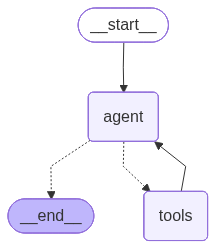

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
from langchain_core.messages import HumanMessage

# query = 'what currency is in Billy Giles\' birthplace? Find the currency and email it to cleftin02@gamil.com'
query = 'Attention is All You Need라는 논문을 요약해서 cleftin02@gamil.com으로 메일 보내주세요'
# query = '일반인이 1주택이며, 집이 15억 일 때 종합부동산세를 추정으로로 계산해 줄 수 있나요?'

for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Attention is All You Need라는 논문을 요약해서 cleftin02@gamil.com으로 메일 보내주세요
agent messages == [HumanMessage(content='Attention is All You Need라는 논문을 요약해서 cleftin02@gamil.com으로 메일 보내주세요', additional_kwargs={}, response_metadata={}, id='3131305b-279d-404d-ae4d-4ac8cbf8d04b')] 
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_RgorCnDrubYAfHlQI0AuQbWb)
 Call ID: call_RgorCnDrubYAfHlQI0AuQbWb
  Args:
    query: Attention is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the 

In [24]:
# from langchain_core.messages import HumanMessage

# graph.invoke({'messages': [HumanMessage('3에다 5를 더하고 거기에 8을 곱하면?')]})